# Level 2 – Task 2: Wine Quality Prediction

## Objective

The objective of this project is to build and compare multiple machine learning classification models to predict wine quality based on its physicochemical properties such as acidity, density, sulphates, alcohol content, and other chemical characteristics.

## Dataset

The **Wine Quality Dataset (Red & White Wine)** from Kaggle is used for this project.

The dataset contains physicochemical measurements of wines along with their quality scores. The original quality scores are transformed into two classification categories:

- **Bad Wine:** Quality < 7
- **Good Wine:** Quality >= 7


### Import Libraries and Load the Dataset

In [1]:
#wine-quality-white-and-red.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)


In [2]:
df = pd.read_csv("wine-quality-white-and-red.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
df.shape

(6497, 13)

### Basic Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [6]:
df.columns

Index(['type', 'fixed acidity', 'volatile acidity', 'citric acid',
       'residual sugar', 'chlorides', 'free sulfur dioxide',
       'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol',
       'quality'],
      dtype='object')

In [7]:
df.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1177)

In [9]:
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

### Data Cleaning

In [10]:
df = df.dropna()

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(5320, 13)

### Analyze Quality Distribution

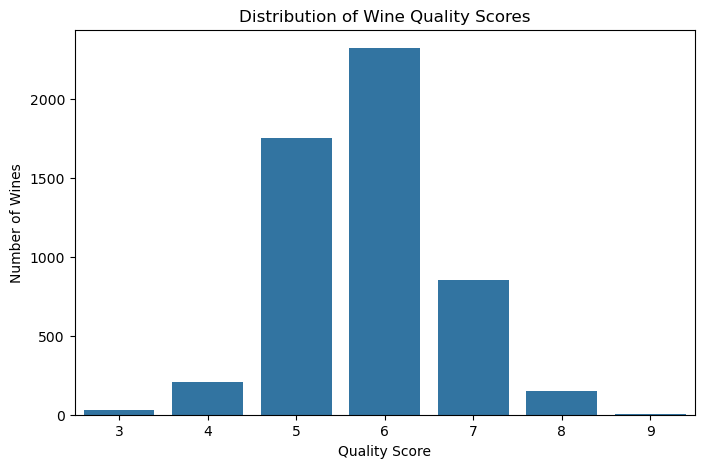

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

In [14]:
df["quality"].value_counts().sort_index()

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

### EDA for Chemical Features

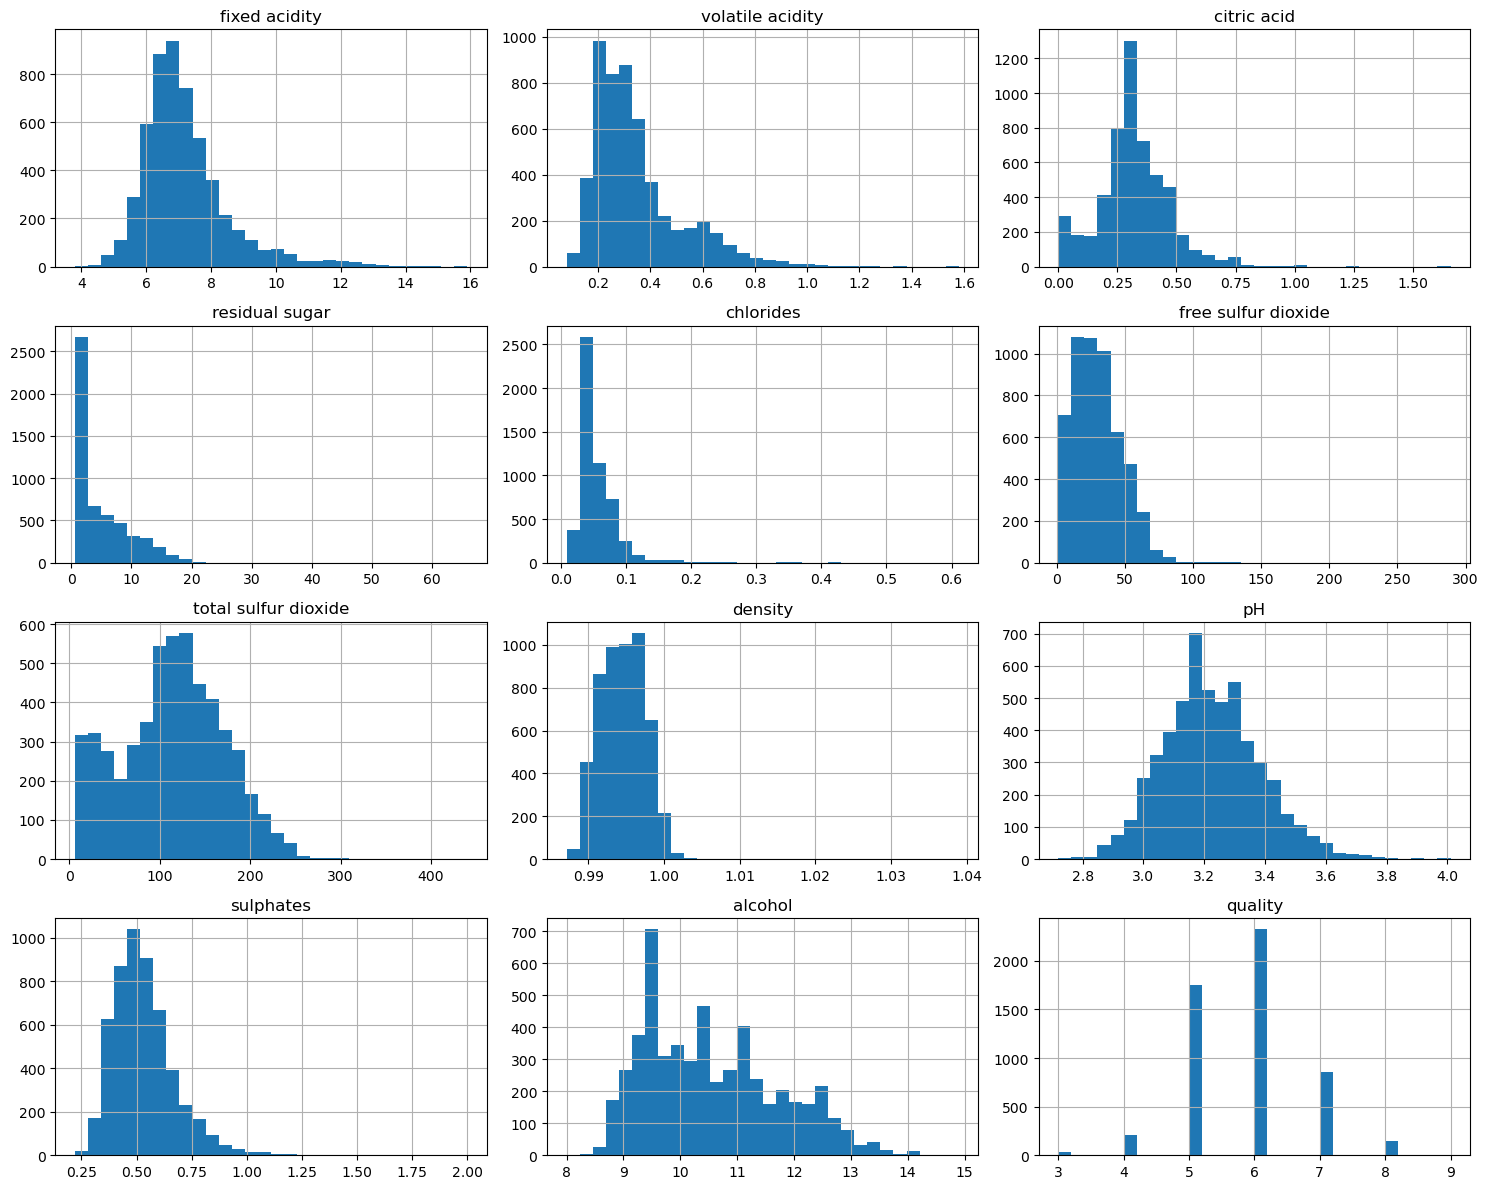

In [15]:
df.hist(
    figsize=(15,12),
    bins=30
)

plt.tight_layout()
plt.show()

### Correlation Heatmap

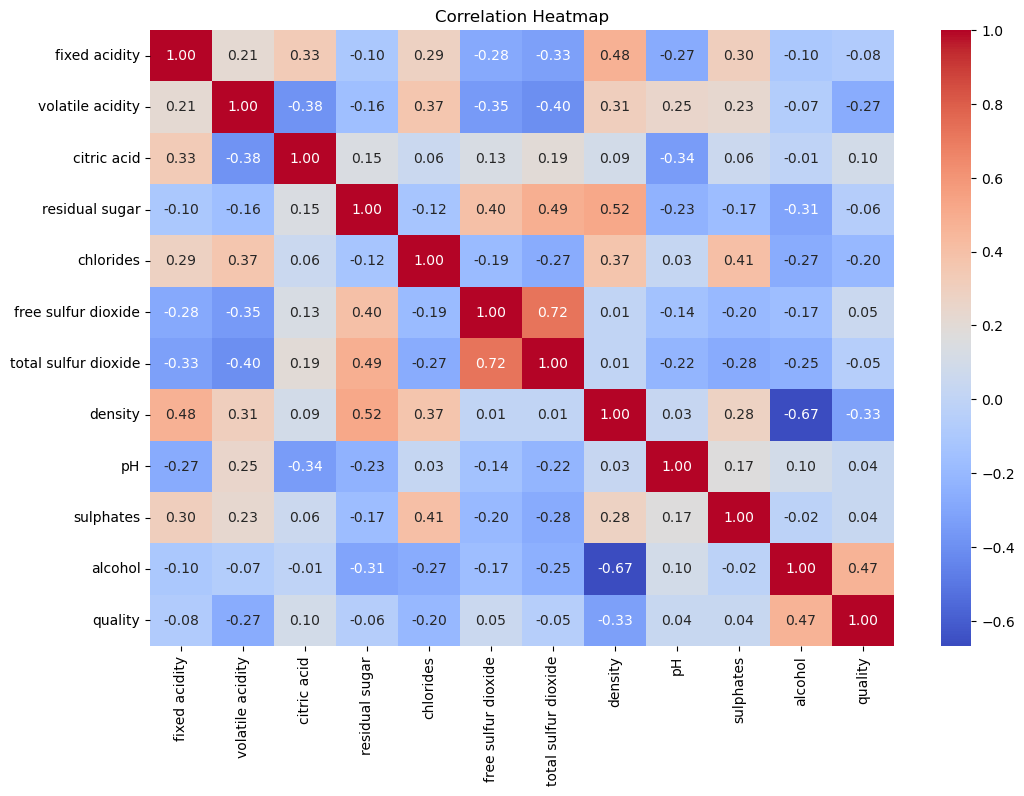

In [17]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Feature Engineering

In [18]:
df["quality_label"] = np.where(
    df["quality"] >= 7,
    1,
    0
)

In [19]:
df["quality_label"].value_counts()

quality_label
0    4311
1    1009
Name: count, dtype: int64

In [20]:
df["quality_label"].value_counts(normalize=True) * 100

quality_label
0    81.033835
1    18.966165
Name: proportion, dtype: float64

### Class Imbalance

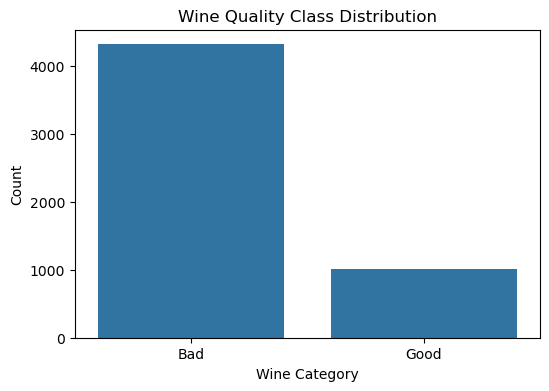

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="quality_label"
)

plt.xticks(
    [0, 1],
    ["Bad", "Good"]
)

plt.title("Wine Quality Class Distribution")
plt.xlabel("Wine Category")
plt.ylabel("Count")

plt.show()

### Prepare Features and Target

In [22]:
X = df.drop(
    columns=["quality", "quality_label"]
)

y = df["quality_label"]

In [23]:
X = pd.get_dummies(
    X,
    columns=["type"],
    drop_first=True
)

### Train-Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Feature Scaling

In [25]:
scaler = StandardScaler()

### Model 1 — Random Forest

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [28]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [29]:
rf_pred = rf_model.predict(X_test)

### Model 2 — SGD Classifier

In [30]:
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SGDClassifier(
        random_state=42,
        class_weight="balanced",
        max_iter=2000
    ))
])

In [31]:
sgd_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 SGDClassifier(class_weight='balanced', max_iter=2000,
                               random_state=42))])

In [32]:
sgd_pred = sgd_model.predict(X_test)

### Model 3 — Support Vector Classifier

In [35]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        class_weight="balanced",
        random_state=42
    ))
])

In [36]:
svc_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(class_weight='balanced', random_state=42))])

In [37]:
svc_pred = svc_model.predict(X_test)

### Evaluate the Models

In [39]:
# Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
Accuracy : 0.849624060150376
Precision: 0.7019230769230769
Recall   : 0.3613861386138614
F1 Score : 0.477124183006536


In [41]:
# SGD Classifier
sgd_accuracy = accuracy_score(y_test, sgd_pred)
sgd_precision = precision_score(y_test, sgd_pred)
sgd_recall = recall_score(y_test, sgd_pred)
sgd_f1 = f1_score(y_test, sgd_pred)

print("SGD Classifier")
print("Accuracy :", sgd_accuracy)
print("Precision:", sgd_precision)
print("Recall   :", sgd_recall)
print("F1 Score :", sgd_f1)

SGD Classifier
Accuracy : 0.7236842105263158
Precision: 0.3838383838383838
Recall   : 0.7524752475247525
F1 Score : 0.5083612040133779


In [42]:
# Support Vector Classifier
svc_accuracy = accuracy_score(y_test, svc_pred)
svc_precision = precision_score(y_test, svc_pred)
svc_recall = recall_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred)

print("SVC")
print("Accuracy :", svc_accuracy)
print("Precision:", svc_precision)
print("Recall   :", svc_recall)
print("F1 Score :", svc_f1)

SVC
Accuracy : 0.7396616541353384
Precision: 0.40601503759398494
Recall   : 0.801980198019802
F1 Score : 0.5391014975041597


In [43]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],
    "Precision": [
        rf_precision,
        sgd_precision,
        svc_precision
    ],
    "Recall": [
        rf_recall,
        sgd_recall,
        svc_recall
    ],
    "F1 Score": [
        rf_f1,
        sgd_f1,
        svc_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.849624,0.701923,0.361386,0.477124
1,SGD Classifier,0.723684,0.383838,0.752475,0.508361
2,SVC,0.739662,0.406015,0.801980,0.539101


### Confusion Matrix

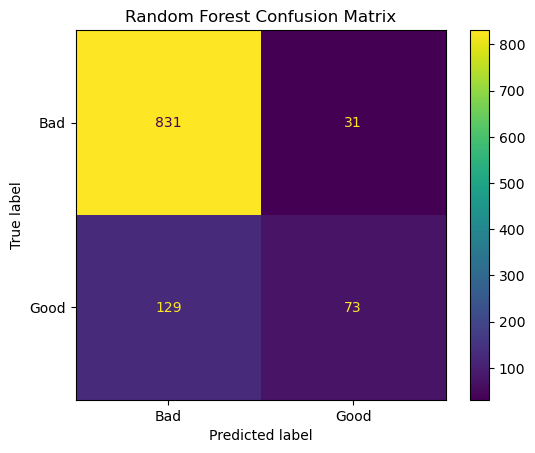

In [44]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bad", "Good"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Model Comparison Table

In [45]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD Classifier",
        "SVC"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, sgd_pred),
        precision_score(y_test, svc_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, sgd_pred),
        recall_score(y_test, svc_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, sgd_pred),
        f1_score(y_test, svc_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.849624,0.701923,0.361386,0.477124
1,SGD Classifier,0.723684,0.383838,0.752475,0.508361
2,SVC,0.739662,0.406015,0.801980,0.539101


In [46]:
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVC,0.739662,0.406015,0.801980,0.539101
1,SGD Classifier,0.723684,0.383838,0.752475,0.508361
0,Random Forest,0.849624,0.701923,0.361386,0.477124


### Random Forest Feature Importance

In [47]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

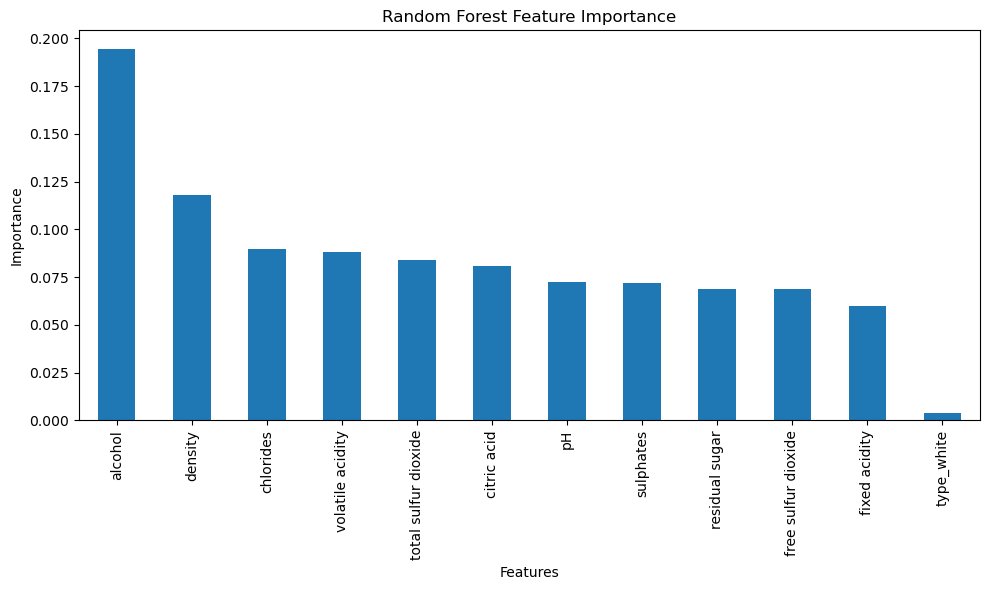

In [48]:
plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.tight_layout()
plt.show()

### Final Conclusion

The Wine Quality Prediction project successfully demonstrated the application of machine learning classification techniques to predict wine quality based on its physicochemical properties.

The dataset was first explored and cleaned by checking missing values, duplicate records, feature distributions, quality-score distribution, and correlations between chemical properties. The original quality scores were transformed into two classes: **Bad (quality < 7)** and **Good (quality ≥ 7)**. Since the target classes were imbalanced, stratified train-test splitting and class balancing techniques were used to improve model reliability.

Three classification models were trained and evaluated:

- **Random Forest Classifier**
- **Stochastic Gradient Descent (SGD) Classifier**
- **Support Vector Classifier (SVC)**

The models were compared using **Accuracy, Precision, Recall, and F1-Score**, along with confusion matrices. The **F1-Score** was given particular importance because of the class imbalance in the dataset.

Based on the evaluation results, the model with the highest overall F1-Score was considered the most suitable model for predicting wine quality. The Random Forest model was also analyzed using feature importance to identify the physicochemical properties that contributed most to the predictions.

Overall, this project provided practical experience in **data preprocessing, exploratory data analysis, feature engineering, handling class imbalance, classification modeling, model evaluation, and model comparison**. The final model can serve as a foundation for an automated wine-quality classification system.